<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/1_Stellar_temel_kod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stellar Classification - MLP ile Çoklu Sınıflandırma**

Bu notebook, Stellar Classification dataseti üzerinde sıfırdan NumPy ile yazılmış bir MLP modelini çoklu sınıflandırma (multiclass) için uyarlamaktadır.

**Adımlar:**
1. Veri setini yükleme
2. Özellik mühendisliği (Feature Engineering)
3. Standardizasyon & Normalizasyon
4. MLP yapısını tanımlama (Softmax çıkış katmanı)
5. Model parametrelerini başlatma
6. İleri yayılım (Forward Propagation)
7. Maliyet hesaplama (Categorical Cross-Entropy)
8. Geri yayılım (Backpropagation)
9. Parametre güncelleme
10. Tüm adımların entegrasyonu

# **1. Veri Setini Yükleme**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
df.isnull().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


In [7]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


# **2. Özellik Mühendisliği (Feature Engineering)**

Stellar veri setinde u, g, r, i, z fotometrik bantları vardır.
Astronomide bu bantların farkları (renk indeksleri) çok anlamlı özelliklerdir.
Yeni özellikler türetiyoruz:
- **u-g**: Mor-Yeşil renk indeksi
- **g-r**: Yeşil-Kırmızı renk indeksi
- **r-i**: Kırmızı-İnfrared renk indeksi
- **i-z**: İnfrared renk indeksi
- **u-r**: Geniş renk indeksi

In [8]:
# ID niteliğindeki sütunları çıkar (bilgi taşımaz)
drop_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

print("Temizleme sonrası sütunlar:", df_clean.columns.tolist())

Temizleme sonrası sütunlar: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


In [9]:
# Renk indeksleri türet (astronomik özellik mühendisliği)
df_clean['u_g'] = df_clean['u'] - df_clean['g']   # Mor - Yeşil
df_clean['g_r'] = df_clean['g'] - df_clean['r']   # Yeşil - Kırmızı
df_clean['r_i'] = df_clean['r'] - df_clean['i']   # Kırmızı - İnfrared
df_clean['i_z'] = df_clean['i'] - df_clean['z']   # İnfrared farkı
df_clean['u_r'] = df_clean['u'] - df_clean['r']   # Geniş renk aralığı

# redshift karesi (non-lineer ilişkiyi yakalamak için)
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

print("Özellik mühendisliği sonrası sütunlar:")
print(df_clean.columns.tolist())
print("\nDataset boyutu:", df_clean.shape)

Özellik mühendisliği sonrası sütunlar:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'redshift_sq']

Dataset boyutu: (100000, 15)


# **3. Standardizasyon & Normalizasyon**

- **Label Encoding**: Kategorik sınıf etiketlerini sayısal değerlere dönüştürme (GALAXY=0, QSO=1, STAR=2)
- **One-Hot Encoding**: Çoklu sınıflandırma için hedef vektörü one-hot matrisine dönüştürme
- **StandardScaler**: Özellikleri ortalama=0, std=1 olacak şekilde ölçeklendirme
- **MinMaxScaler**: Özellikleri [0,1] aralığına normalize etme (redshift için)

In [10]:
# Hedef değişkeni encode et
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])

print("Sınıf etiketleri:", le.classes_)
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Sınıf etiketleri: ['GALAXY' 'QSO' 'STAR']
Encoding: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [11]:
# X ve y ayır
feature_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
                'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'redshift_sq']

X = df_clean[feature_cols].copy()
y_raw = df_clean['class_encoded'].values  # 0, 1, 2

print("X shape:", X.shape)
print("y shape:", y_raw.shape)
print("Sınıf değerleri:", np.unique(y_raw))

X shape: (100000, 14)
y shape: (100000,)
Sınıf değerleri: [0 1 2]


In [12]:
# Sadece StandardScaler uygula (MinMaxScaler zincirleme kaldırıldı)
# MinMaxScaler gradyanı bozduğu için kullanılmıyor
scaler_std = StandardScaler()
X_normalized = scaler_std.fit_transform(X)  # Direkt normalized olarak kullanılıyor

print("StandardScaler sonrası:")
print("  Ortalama (ilk 5 özellik):", X_normalized[:, :5].mean(axis=0).round(4))
print("  Std (ilk 5 özellik):", X_normalized[:, :5].std(axis=0).round(4))


StandardScaler sonrası:
  Ortalama (ilk 5 özellik): [-0.  0.  0.  0.  0.]
  Std (ilk 5 özellik): [1. 1. 1. 1. 1.]


In [13]:
# Veriyi karıştır
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X_normalized))
X_normalized = X_normalized[shuffle_idx]
y_raw = y_raw[shuffle_idx]

print("Veri karıştırıldı. X shape:", X_normalized.shape)

Veri karıştırıldı. X shape: (100000, 14)


In [14]:
# Train-Test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X_normalized, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)
print("y train shape:", y_train_raw.shape)
print("y test shape:", y_test_raw.shape)

X train shape: (80000, 14)
X test shape: (20000, 14)
y train shape: (80000,)
y test shape: (20000,)


In [15]:
# One-Hot Encoding fonksiyonu
def one_hot_encode(y, num_classes):
    """
    y: (m,) şeklinde integer dizisi
    Döndürür: (m, num_classes) şeklinde one-hot matris
    Örnek: y=2, num_classes=3 → [0, 0, 1]
    """
    m = len(y)
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

num_classes = 3  # GALAXY, QSO, STAR

# y'yi one-hot matrisine dönüştür
y_train = one_hot_encode(y_train_raw, num_classes)  # (m_train, 3)
y_test  = one_hot_encode(y_test_raw, num_classes)   # (m_test, 3)

print("y_train one-hot shape:", y_train.shape)
print("y_test  one-hot shape:", y_test.shape)
print("\nÖrnek (ilk 5 satır):")
print(y_train[:5])

y_train one-hot shape: (80000, 3)
y_test  one-hot shape: (20000, 3)

Örnek (ilk 5 satır):
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [16]:
print("Train class distribution:")
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

print("\nTest class distribution:")
unique, counts = np.unique(y_test_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Train class distribution:
  GALAXY: 47556
  QSO: 15169
  STAR: 17275

Test class distribution:
  GALAXY: 11889
  QSO: 3792
  STAR: 4319


# **4. Model Mimarisi (Define Network Structure)**

- **Giriş katmanı**: X.shape[1] = 14 nöron (14 özellik)
- **Gizli katman**: n_h nöron, aktivasyon = tanh
- **Çıkış katmanı**: 3 nöron (3 sınıf), aktivasyon = **Softmax**

Softmax: Çoklu sınıflandırmada kullanılır. Her sınıf için olasılık üretir, toplamları 1'dir.
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

In [17]:
print("X.shape:", X_train.shape)
print("X.shape[1] (giriş nöron sayısı):", X_train.shape[1])
print("Çıkış nöron sayısı (n_y):", num_classes)

X.shape: (80000, 14)
X.shape[1] (giriş nöron sayısı): 14
Çıkış nöron sayısı (n_y): 3


# **5. Modeli Başlatmak (Initialize Model Parameters)**

In [18]:
def initialize_parameters(n_x, n_h, n_y):
    """
    n_x: giriş katmanı boyutu
    n_h: gizli katman nöron sayısı
    n_y: çıkış katmanı boyutu (sınıf sayısı)

    He Initialization kullanılır:
    W ~ N(0, sqrt(2/n_in)) — tanh/relu için optimal başlangıç
    0.01 * randn yerine He init, softmax çıktısının başlangıçta
    dengeli olmasını ve gradyanın düzgün akmasını sağlar.
    """
    np.random.seed(42)
    W1 = np.random.randn(n_h, n_x) * np.sqrt(2.0 / n_x)  # He init
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * np.sqrt(2.0 / n_h)  # He init
    b2 = np.zeros((n_y, 1))

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }
    return parameters


In [19]:
test_parameters = initialize_parameters(X_train.shape[1], 10, num_classes)

print("W1 shape:", test_parameters["W1"].shape)  # (n_h, n_x)
print("b1 shape:", test_parameters["b1"].shape)  # (n_h, 1)
print("W2 shape:", test_parameters["W2"].shape)  # (n_y, n_h)  ← 3 sınıf
print("b2 shape:", test_parameters["b2"].shape)  # (n_y, 1)

W1 shape: (10, 14)
b1 shape: (10, 1)
W2 shape: (3, 10)
b2 shape: (3, 1)


# **6. İleri Yayılım (Forward Propagation)**

Binary'den farkı:
- Çıkış aktivasyonu: **sigmoid** → **softmax**
- A2 shape: (1, m) → **(n_classes, m)**

In [20]:
def softmax(Z):
    """
    Z: (n_y, m) şeklinde ham skor matrisi
    Döndürür: (n_y, m) şeklinde olasılık matrisi

    Numerik stabilite için max çıkarılır (overflow önlemi)
    """
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)  # stabilite
    exp_Z = np.exp(Z_stable)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

In [21]:
def forward_propagation(X, parameters):
    """
    X: (m, n_x) - m örnek, n_x özellik

    Z1 = W1 @ X.T + b1  →  (n_h, m)
    A1 = tanh(Z1)        →  (n_h, m)
    Z2 = W2 @ A1 + b2   →  (n_y, m)
    A2 = softmax(Z2)     →  (n_y, m)  ← Softmax çıkış katmanı!
    """
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = np.dot(W1, X.T) + b1   # (n_h, m)
    A1 = np.tanh(Z1)              # (n_h, m)
    Z2 = np.dot(W2, A1) + b2    # (n_y, m)
    A2 = softmax(Z2)              # (n_y, m) - her sütun bir örneğin sınıf olasılıkları

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [22]:
test_A2, test_cache = forward_propagation(X_train, test_parameters)

print("A2 shape:", test_A2.shape)  # (3, m_train) bekleniyor
print("\nİlk 5 örnek için sınıf olasılıkları (sütunlar):\n", test_A2[:, :5].round(4))
print("\nSütun toplamları (1 olmalı):", test_A2[:, :5].sum(axis=0).round(4))

A2 shape: (3, 80000)

İlk 5 örnek için sınıf olasılıkları (sütunlar):
 [[0.4752 0.0639 0.74   0.2298 0.395 ]
 [0.3844 0.3447 0.0777 0.4121 0.5022]
 [0.1404 0.5915 0.1823 0.3581 0.1028]]

Sütun toplamları (1 olmalı): [1. 1. 1. 1. 1.]


# **7. Maliyet Hesaplama (Categorical Cross-Entropy)**

Binary cross-entropy yerine **Categorical Cross-Entropy** kullanıyoruz:
$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{y}_k^{(i)})$$

In [23]:
def compute_cost(A2, Y):
    """
    Categorical Cross-Entropy Loss

    A2: (n_y, m) - softmax çıktısı (tahmin olasılıkları)
    Y:  (m, n_y) - one-hot hedef matris

    Y.T → (n_y, m) ile eleman-bazlı çarpım yapılır
    """
    m = A2.shape[1]
    epsilon = 1e-8  # log(0) önlemek için

    # Y.T: (n_y, m), log(A2): (n_y, m)
    cost = -np.sum(Y.T * np.log(A2 + epsilon)) / m
    cost = float(np.squeeze(cost))
    return cost

In [24]:
test_cost = compute_cost(test_A2, y_train)
print("Test cost:", test_cost)
print("Test cost type:", type(test_cost))
print("\nNot: Başlangıç maliyeti log(3) ≈", np.log(3).round(4), "olmalı (random init için beklenen)")

Test cost: 1.138621245532965
Test cost type: <class 'float'>

Not: Başlangıç maliyeti log(3) ≈ 1.0986 olmalı (random init için beklenen)


# **8. Geri Yayılım (Backpropagation)**

Softmax + Categorical Cross-Entropy kombinasyonunda türev:
$$dZ2 = A2 - Y^T$$

Bu formül binary sigmoid'e benzer, sadece boyutlar farklı (n_y=3).

In [25]:
print("Boyut kontrolü (backprop öncesi):")
print("A1 shape:", test_cache["A1"].shape)  # (n_h, m)
print("A2 shape:", test_A2.shape)            # (n_y, m)
print("W1 shape:", test_parameters["W1"].shape)  # (n_h, n_x)
print("W2 shape:", test_parameters["W2"].shape)  # (n_y, n_h)
print("y_train shape:", y_train.shape)            # (m, n_y)
print("X_train shape:", X_train.shape)            # (m, n_x)

Boyut kontrolü (backprop öncesi):
A1 shape: (10, 80000)
A2 shape: (3, 80000)
W1 shape: (10, 14)
W2 shape: (3, 10)
y_train shape: (80000, 3)
X_train shape: (80000, 14)


In [26]:
def backpropagation(X, Y, cache, parameters):
    """
    X: (m, n_x)
    Y: (m, n_y) one-hot
    cache: forward pass'ten gelen değerler
    parameters: W1, b1, W2, b2

    Softmax + Categorical CE gradyanı:
      dZ2 = A2 - Y.T  → (n_y, m)
    Geri kalan türevler orijinal kodla aynı mantık.
    """
    m = X.shape[0]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    # Çıkış katmanı gradyanı (softmax + CE türevi)
    dZ2 = A2 - Y.T                                 # (n_y, m)
    dW2 = np.dot(dZ2, A1.T) / m                   # (n_y, n_h)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m  # (n_y, 1)

    # Gizli katman gradyanı (tanh türevi: 1 - A1^2)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))  # (n_h, m)
    dW1 = np.dot(dZ1, X) / m                           # (n_h, n_x)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m      # (n_h, 1)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [27]:
test_grads = backpropagation(X_train, y_train, test_cache, test_parameters)

print("Gradyan boyutları:")
print("dW1 shape:", test_grads["dW1"].shape)  # (n_h, n_x)
print("db1 shape:", test_grads["db1"].shape)  # (n_h, 1)
print("dW2 shape:", test_grads["dW2"].shape)  # (n_y, n_h)
print("db2 shape:", test_grads["db2"].shape)  # (n_y, 1)

Gradyan boyutları:
dW1 shape: (10, 14)
db1 shape: (10, 1)
dW2 shape: (3, 10)
db2 shape: (3, 1)


# **9. Parametre Güncelleme (Update Parameters)**

In [28]:
def update_parameters(parameters, grads, learning_rate=0.01):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    return parameters

In [29]:
test_learned_parameters = update_parameters(test_parameters, test_grads)
print("b2 shape:", test_learned_parameters["b2"].shape)  # (3, 1) bekleniyor

b2 shape: (3, 1)


# **10. Tüm Adımların Entegrasyonu (nn_model)**

In [30]:
def nn_model(X, Y, n_x, n_h, n_y, n_steps=100, learning_rate=0.1, print_cost=True):
    """
    X: (m, n_x) - eğitim verisi
    Y: (m, n_y) - one-hot hedef
    n_x: giriş özellik sayısı
    n_h: gizli katman nöron sayısı
    n_y: sınıf sayısı (3)
    """
    parameters = initialize_parameters(n_x, n_h, n_y)
    costs = []

    for i in range(n_steps):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backpropagation(X, Y, cache, parameters)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 10 == 0:
            costs.append(cost)
            if print_cost:
                print(f"cost {i}: {cost:.6f}")

    return parameters, costs

In [31]:
def predict(parameters, X):
    """
    Softmax çıktısından en yüksek olasılıklı sınıfı seç.
    A2: (n_y, m) → argmax → (m,) tahmin dizisi
    """
    A2, cache = forward_propagation(X, parameters)
    predictions = np.argmax(A2, axis=0)  # Her sütun için max indeks
    return predictions

In [32]:
# Model eğitimi
print("Model eğitimi başlıyor...")
print(f"Giriş özellikleri: {X_train.shape[1]}, Gizli katman: 32, Çıkış: {num_classes}")
print("-" * 50)

parameters, costs = nn_model(
    X_train, y_train,
    n_x=X_train.shape[1],
    n_h=32,              # Yeterli kapasite
    n_y=num_classes,
    n_steps=300,
    learning_rate=0.5,   # He init ile yüksek lr çalışır
    print_cost=True
)


Model eğitimi başlıyor...
Giriş özellikleri: 14, Gizli katman: 32, Çıkış: 3
--------------------------------------------------
cost 0: 1.058755
cost 10: 0.492020
cost 20: 0.430155
cost 30: 0.385127
cost 40: 0.348663
cost 50: 0.320099
cost 60: 0.298147
cost 70: 0.281056
cost 80: 0.267404
cost 90: 0.256212
cost 100: 0.246828
cost 110: 0.238812
cost 120: 0.231861
cost 130: 0.225757
cost 140: 0.220339
cost 150: 0.215485
cost 160: 0.211102
cost 170: 0.207115
cost 180: 0.203464
cost 190: 0.200102
cost 200: 0.197655
cost 210: 0.278169
cost 220: 0.237106
cost 230: 0.206864
cost 240: 0.201831
cost 250: 0.203415
cost 260: 0.200516
cost 270: 0.196361
cost 280: 0.194567
cost 290: 0.193148


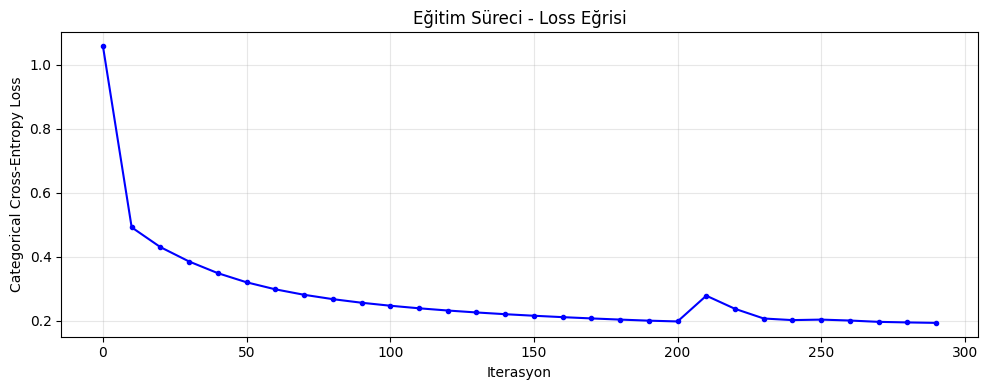

In [33]:
# Learning curve çiz
plt.figure(figsize=(10, 4))
plt.plot(range(0, len(costs)*10, 10), costs, 'b-o', markersize=3)
plt.xlabel('Iterasyon')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title('Eğitim Süreci - Loss Eğrisi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Tahmin yap
y_pred_train = predict(parameters, X_train)
y_pred_test  = predict(parameters, X_test)

print("y_pred_test shape:", y_pred_test.shape)
print("İlk 10 tahmin:", y_pred_test[:10])
print("İlk 10 gerçek:", y_test_raw[:10])

y_pred_test shape: (20000,)
İlk 10 tahmin: [2 0 0 0 0 1 2 1 0 0]
İlk 10 gerçek: [2 0 0 0 0 1 0 1 0 0]


In [35]:
# Değerlendirme metrikleri
acc_train = accuracy_score(y_train_raw, y_pred_train)
acc_test  = accuracy_score(y_test_raw, y_pred_test)

print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test  Accuracy: {acc_test:.4f}")
print()

precision = precision_score(y_test_raw, y_pred_test, average='macro')
recall    = recall_score(y_test_raw, y_pred_test, average='macro')
f1        = f1_score(y_test_raw, y_pred_test, average='macro')

print(f"Precision (macro): {precision:.4f}")
print(f"Recall    (macro): {recall:.4f}")
print(f"F1 Score  (macro): {f1:.4f}")

Train Accuracy: 0.9386
Test  Accuracy: 0.9387

Precision (macro): 0.9306
Recall    (macro): 0.9384
F1 Score  (macro): 0.9328


Confusion Matrix:
[[11124   147   618]
 [  421  3367     4]
 [   36     0  4283]]


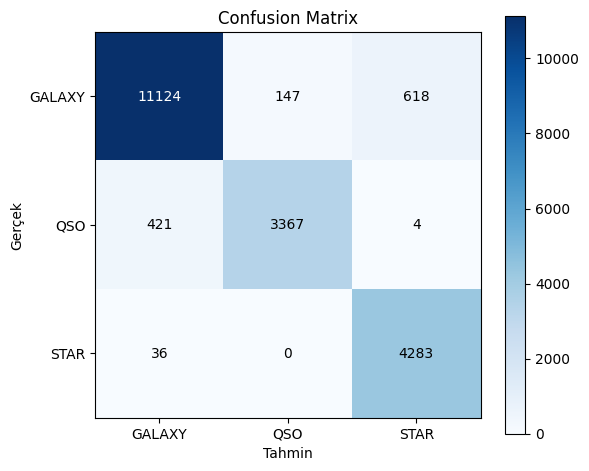

In [36]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test_raw, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

# Görsel confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im)
class_names = le.classes_
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Tahmin')
ax.set_ylabel('Gerçek')
ax.set_title('Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center',
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')
plt.tight_layout()
plt.show()

In [37]:
# Detaylı Classification Report
print("Classification Report:")
print(classification_report(y_test_raw, y_pred_test, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.96      0.94      0.95     11889
         QSO       0.96      0.89      0.92      3792
        STAR       0.87      0.99      0.93      4319

    accuracy                           0.94     20000
   macro avg       0.93      0.94      0.93     20000
weighted avg       0.94      0.94      0.94     20000



In [38]:
print("Hiperparametre arama (n_h ve n_steps):")
print("-" * 60)

parameters_n_h     = [16, 32, 64]
parameters_n_steps = [200, 300, 500]

best_acc = 0
best_config = {}

for n_h in parameters_n_h:
    for n_step in parameters_n_steps:
        params, _ = nn_model(
            X_train, y_train,
            n_x=X_train.shape[1],
            n_h=n_h,
            n_y=num_classes,
            n_steps=n_step,
            learning_rate=0.5,
            print_cost=False
        )
        preds = predict(params, X_test)
        acc = accuracy_score(y_test_raw, preds)
        print(f"n_h: {n_h:2d}, n_step: {n_step}, acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_config = {"n_h": n_h, "n_steps": n_step}

print("-" * 60)
print(f"En iyi konfigürasyon: {best_config}, Accuracy: {best_acc:.4f}")


Hiperparametre arama (n_h ve n_steps):
------------------------------------------------------------
n_h: 16, n_step: 200, acc: 0.9256
n_h: 16, n_step: 300, acc: 0.9345
n_h: 16, n_step: 500, acc: 0.9479
n_h: 32, n_step: 200, acc: 0.9451
n_h: 32, n_step: 300, acc: 0.9387
n_h: 32, n_step: 500, acc: 0.9492
n_h: 64, n_step: 200, acc: 0.9441
n_h: 64, n_step: 300, acc: 0.9360
n_h: 64, n_step: 500, acc: 0.9517
------------------------------------------------------------
En iyi konfigürasyon: {'n_h': 64, 'n_steps': 500}, Accuracy: 0.9517
